## Department of Electronics and Telecommunications Engineering
## EN 3160
## Intensity Transformations and Neighborhood Filtering

#### Name: K. D. Manatunga
#### Index Number: 230395T

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

#### Question 01

In [2]:
im1 = cv.imread("Images/emma.jpg",cv.IMREAD_GRAYSCALE)

In [37]:
breakpoints = np.array([
    [0, 0],
    [50, 50],
    [50, 100],
    [150, 255],
    [150, 150],
    [255, 255]
], dtype=np.float32)

In [41]:
def intensity_transform(im, bp):
    x = im.astype(np.float32)
    y = np.zeros_like(x)

    for i in range(0, len(bp) - 1, 2):
        x1, y1 = bp[i]
        x2, y2 = bp[i + 1]

        if i == len(bp) - 2:
            mask = (x >= x1) & (x <= x2)
        else:
            mask = (x >= x1) & (x < x2)

        y[mask] = y1 + (y2 - y1) * (x[mask] - x1) / (x2 - x1)

    return np.clip(y, 0, 255).astype(np.uint8)

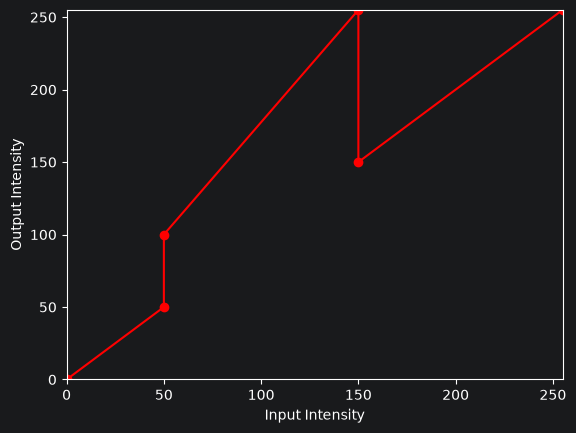

In [42]:
r1 = intensity_transform(im1, breakpoints)

plt.plot(breakpoints[:, 0], breakpoints[:, 1], marker='o', color='red')

plt.xlabel("Input Intensity")
plt.ylabel("Output Intensity")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.show()

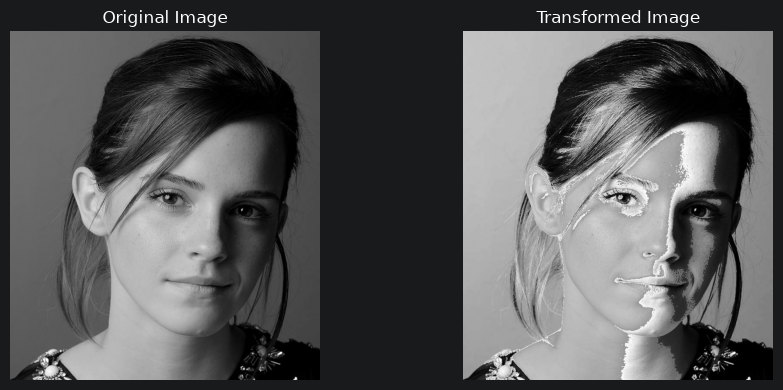

In [43]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(im1, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(r1, cmap="gray")
plt.title("Transformed Image")
plt.axis("off")

plt.tight_layout()
plt.show()

##### Experimenting Using different breakpoints.

In [70]:
def intensity_transform2(im, breakpoints):
    x = breakpoints[:, 0]
    y = breakpoints[:, 1]

    result = np.interp(im, x, y)

    return np.clip(result, 0, 255).astype(np.uint8)


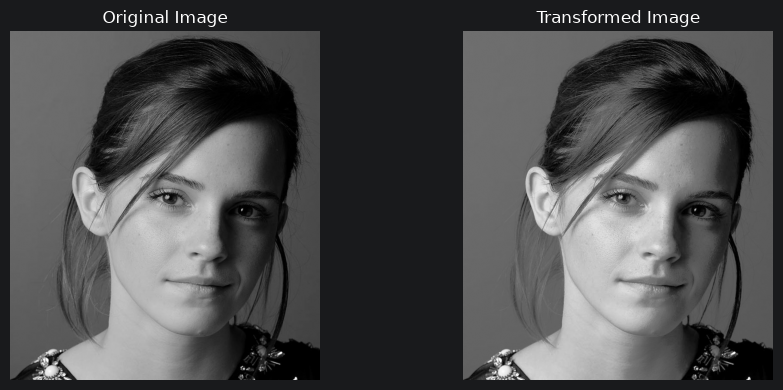

In [71]:
breakpoints2 = np.array([
    [0, 0],
    [50, 80],
    [130, 120],
    [200, 220],
    [255, 255]
], dtype=np.float32)

r2 = intensity_transform2(im1, breakpoints2)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(im1, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(r2, cmap="gray")
plt.title("Transformed Image")
plt.axis("off")

plt.tight_layout()
plt.show()


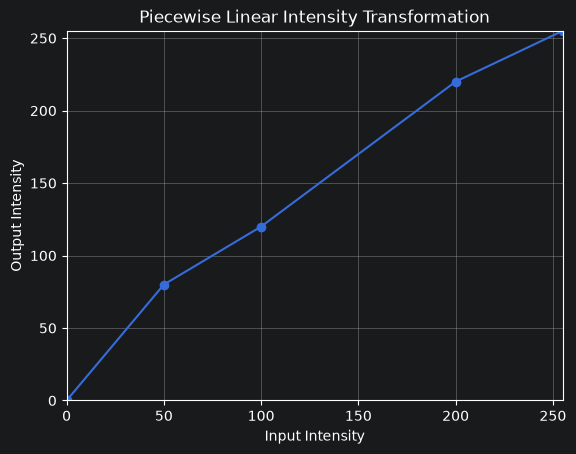

In [8]:
plt.plot(breakpoints2[:, 0], breakpoints2[:, 1], marker="o")
plt.xlabel("Input Intensity")
plt.ylabel("Output Intensity")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid()
plt.title("Piecewise Linear Intensity Transformation")
plt.show()

The breakpoints were adjusted to improve the visual appearance of the image. This transformation expands darker intensity values, making shadow and mid tone details more visible while preserving the high intensity range without clipping excessively. So this transformation improves the contrast while maintaining the natural appearance.

#### Question 2

In [13]:
brain = cv.imread("Images/Fig2.jpeg", cv.IMREAD_GRAYSCALE)
#
# plt.imshow(brain, cmap="gray")
# plt.axis("off")
# plt.show()

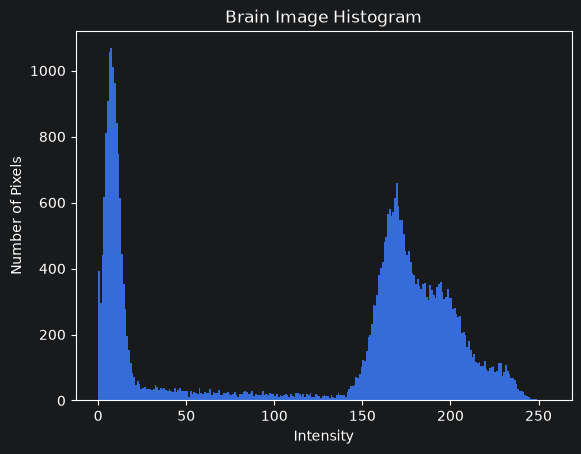

In [12]:
plt.hist(brain.ravel(), bins=256, range=(0, 256))

plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")
plt.title("Brain Image Histogram")

plt.show()

In [20]:
white_bp = np.array([
    [0, 0],
    [130, 20],
    [145, 50],
    [175, 190],
    [205, 225],
    [255, 255]
], dtype=np.float32)

gray_bp = np.array([
    [0, 0],
    [155, 20],
    [175, 50],
    [210, 200],
    [235, 235],
    [255, 255]
], dtype=np.float32)

In [21]:
white_result = intensity_transform(brain, white_bp)
gray_result = intensity_transform(brain, gray_bp)

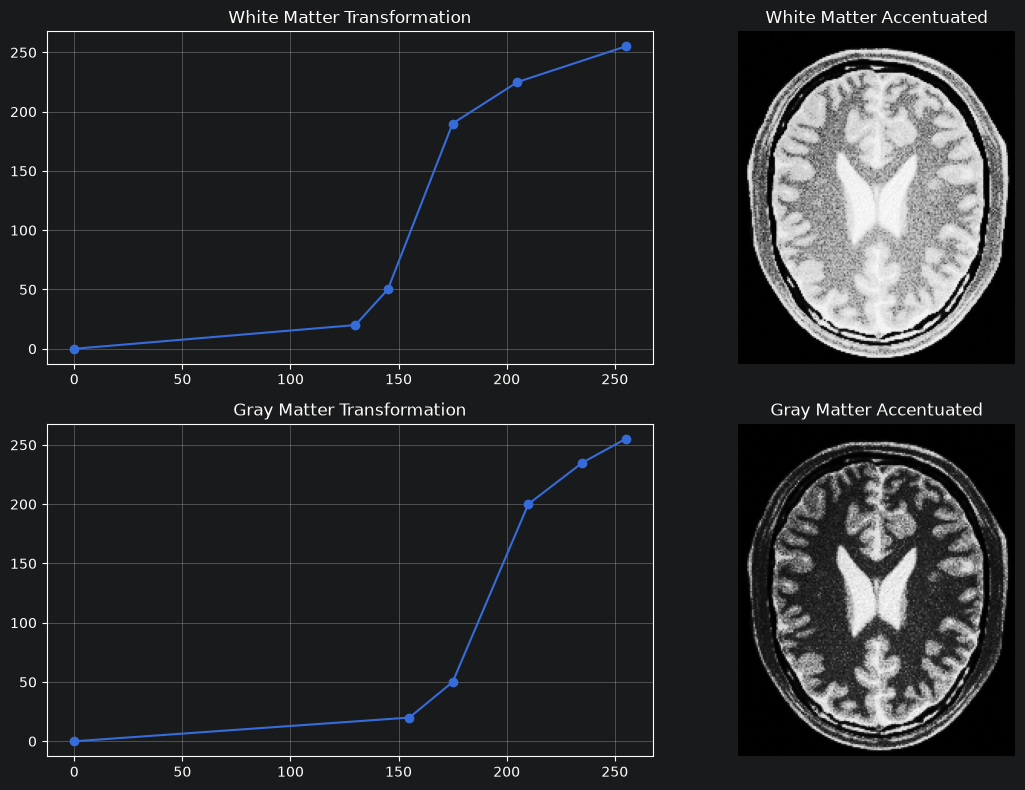

In [22]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(white_bp[:, 0], white_bp[:, 1], marker="o")
plt.title("White Matter Transformation")
plt.grid()

plt.subplot(2, 2, 2)
plt.imshow(white_result, cmap="gray")
plt.title("White Matter Accentuated")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.plot(gray_bp[:, 0], gray_bp[:, 1], marker="o")
plt.title("Gray Matter Transformation")
plt.grid()

plt.subplot(2, 2, 4)
plt.imshow(gray_result, cmap="gray")
plt.title("Gray Matter Accentuated")
plt.axis("off")

plt.tight_layout()
plt.show()

Separate linear transformations were used to expand intensity ranges corresponding to white and gray matter. Increased the slope within the corresponding tissue range inorder to increase the contrast between that surrounding regions.

##### Question 3

In [87]:
im3 = cv.imread("Images/Fig3.jpeg")

lab = cv.cvtColor(im3, cv.COLOR_BGR2LAB)
L, a, b = cv.split(lab)

gamma = 0.7

L_norm = L.astype(np.float32) / 255.0
L_gamma = np.power(L_norm, gamma)
L_gamma = np.clip(L_gamma * 255, 0, 255).astype(np.uint8)

lab_gamma = cv.merge([L_gamma, a, b])

result_3 = cv.cvtColor(lab_gamma, cv.COLOR_LAB2RGB)
im3_rgb = cv.cvtColor(im3, cv.COLOR_BGR2RGB)

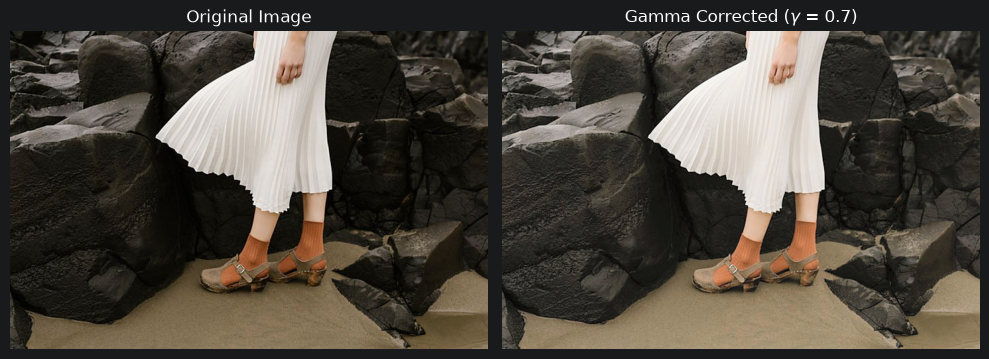

In [88]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(im3_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result_3)
plt.title(f"Gamma Corrected ($\\gamma$ = {gamma})")
plt.axis("off")

plt.tight_layout()
plt.show()

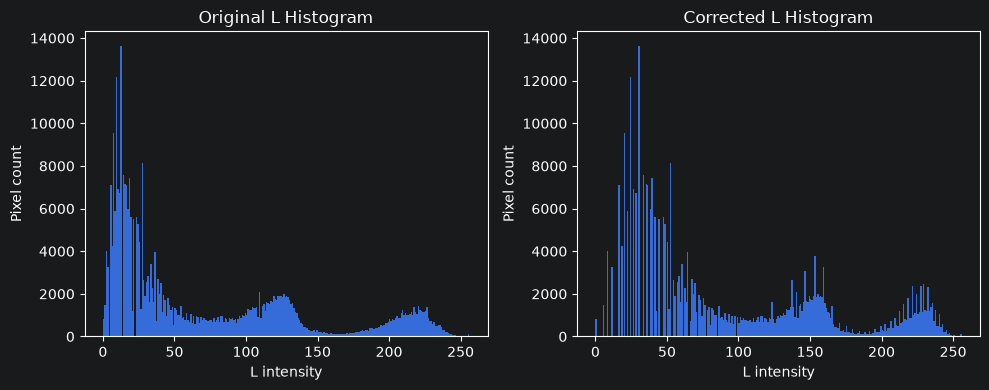

In [90]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(L.ravel(),bins=256,range=(0, 256))
plt.title("Original L Histogram")
plt.xlabel("L intensity")
plt.ylabel("Pixel count")

plt.subplot(1, 2, 2)
plt.hist(L_gamma.ravel(),bins=256,range=(0, 256))
plt.title("Corrected L Histogram")
plt.xlabel("L intensity")
plt.ylabel("Pixel count")

plt.tight_layout()
plt.show()